In [1]:
from dotenv import load_dotenv
load_dotenv()

True

In [3]:
from langgraph.graph import START, END, StateGraph, MessagesState
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode
from typing import Literal

In [4]:
@tool
def get_weather(location: str):
    """Call to get the current weather."""
    if location.lower() in ["munich"]:
        return "It's 15 degrees Celsius and cloudy."
    else:
        return "It's 32 degrees Celsius and sunny."

In [5]:
get_weather.invoke(input={"location": "Munich"})

"It's 15 degrees Celsius and cloudy."

In [6]:
tools=[get_weather]
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash").bind_tools(tools)
llm

RunnableBinding(bound=ChatGoogleGenerativeAI(profile={'max_input_tokens': 1048576, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': True, 'pdf_inputs': True, 'video_inputs': True, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'image_url_inputs': True, 'image_tool_message': True, 'tool_choice': True}, google_api_key=SecretStr('**********'), model='gemini-2.5-flash', client=<google.genai.client.Client object at 0x10bdd9be0>, default_metadata=(), model_kwargs={}), kwargs={'tools': [{'type': 'function', 'function': {'name': 'get_weather', 'description': 'Call to get the current weather.', 'parameters': {'properties': {'location': {'type': 'string'}}, 'required': ['location'], 'type': 'object'}}}]}, config={}, config_factories=[])

In [7]:
llm.invoke("Hello")

AIMessage(content='Hello! How can I help you today?', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019cc19c-c44d-7bb1-a1aa-2189f9f1acc8-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 41, 'output_tokens': 9, 'total_tokens': 50, 'input_token_details': {'cache_read': 0}})

In [8]:
llm.invoke("What's the weather like in Munich?")

AIMessage(content='', additional_kwargs={'function_call': {'name': 'get_weather', 'arguments': '{"location": "Munich"}'}, '__gemini_function_call_thought_signatures__': {'a532c309-3efd-4fde-bada-516292817884': 'CskBAb4+9vu4SiPYe3zWPzidiKcHXeIspDbFimNWDQm89jCpFU2jdUp56cN5i5lTZA4HAxwE9kk+nBd20kyX+/cjRheTVqNYOA+ZdVlKsLWDN/h0pz0Ww7F3dDlhkiUoRlpjgxtaCQyFs93mX3p6pj0cKih/IfeQaUfpT+Nm5Q/UUGQJeoabF1UZunjaOdM0V93otcfP6qdPiZv4YFOkc/8GmaH/j/0xxscrwdREGXH/aQIa1Qh1eoBLEa+NNFVMGYA1bUIFO/0rmBs2'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019cc19d-33ee-7d60-b5d8-af96934aea50-0', tool_calls=[{'name': 'get_weather', 'args': {'location': 'Munich'}, 'id': 'a532c309-3efd-4fde-bada-516292817884', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 49, 'output_tokens': 57, 'total_tokens': 106, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 41}})

In [9]:
def call_model(state: MessagesState):
    msg = state["messages"]
    response = llm.invoke(msg)
    return {"message": response}

def should_continue(state: MessagesState) -> Literal["tool", END]:
    msg = state["messages"]
    last_msg = msg[-1]
    if last_msg.tool_calls:
        return "tool"
    return END

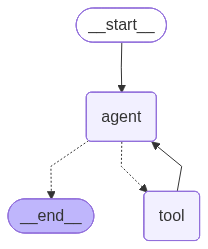

In [10]:
workflow = StateGraph(MessagesState)
tool_node = ToolNode(tools=tools)

workflow.add_node("agent", call_model)
workflow.add_node("tool", tool_node)

workflow.add_edge(START, "agent")
workflow.add_conditional_edges("agent", should_continue)
workflow.add_edge("tool", "agent")

graph = workflow.compile()
graph